In [1]:
import sys
sys.path.append('..')
import nimo
import yaml
import shutil

In [2]:
# Parameters cell for papermill
config_file = "nts_settings.tmpl.yaml"  # This will be overwritten by papermill

In [3]:
# Parameters
config_file = "./configs/nts_conservative_batch48_trial3.yaml"


In [4]:
# Load configuration from YAML file
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

### AIとロボットのサイクルの回数を設定

In [5]:
# CyclesNum will be calculated from total_eval / batch_size

### 目的関数の次元を設定

In [6]:
ObjectivesNum = config["objectives_num"]

In [7]:
from descriptor import Desctiptor
des = Desctiptor()

### 実験条件候補データファイル名および提案条件のファイル名を設定

In [8]:
from pathlib import Path

TRIAL = config["trial"]
BATCH_SIZE = int(config["batch_size"])
TOTAL_EVAL = int(config["total_eval"])
INITIAL_BATCH_SIZE = int(config["initial_batch_size"])
CyclesNum = int((TOTAL_EVAL - INITIAL_BATCH_SIZE) / BATCH_SIZE)
print(f"CyclesNum: {CyclesNum}")
NTS_MODE = config["nts_mode"]
RE_SEED = config["re_seed"]
USE_DPP = config["use_dpp"]

if NTS_MODE == "conservative":
    MODE = nimo.Mode.conservative
elif NTS_MODE == "moderate":
    MODE = nimo.Mode.moderate
elif NTS_MODE == "aggressive":
    MODE = nimo.Mode.aggressive
print(MODE)

# Create output directory with batch size in name
out_dir = Path(f"./data_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}")
out_dir.mkdir(exist_ok=True, parents=True)
(out_dir / "fig").mkdir(exist_ok=True, parents=True)

# Copy setting yaml file to output directory
shutil.copy(config_file, out_dir / Path(config_file).name)

CyclesNum: 14
Mode.conservative


PosixPath('data_conservative_batch48_trial3/nts_conservative_batch48_trial3.yaml')

In [9]:
candidates_file = out_dir / f"descriptor_search_space_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"
proposals_file = out_dir / f"descriptor_proposals_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"

# Copy initial search space to output directory if not exists
import os
initial_search_space = f"./descriptor_search_space_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"
if os.path.exists(initial_search_space) and not os.path.exists(candidates_file):
    shutil.copy(initial_search_space, candidates_file)

### 結果を格納する場所を作成

In [10]:
res_history = nimo.history(input_file = str(candidates_file),
                             num_objectives = ObjectivesNum)

### 最適化計算

In [11]:
import time
start = time.time()
for K in range(CyclesNum+1):

    #最初のサイクルではランダムに実験条件を提案させる
    if K == 0:
        nimo.selection(method = "RE",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = INITIAL_BATCH_SIZE,
                       re_seed = RE_SEED)

    #2回目以降のサイクルではAIを使用して実験条件を提案
    else:
        nimo.selection(method = "NTS",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = BATCH_SIZE,
                       sample_mode=MODE,
                       use_dpp=USE_DPP,
                       output_res=True)

    #実験条件に従い，ロボット実験のインプットファイルを作成する
    import preparation_input_functions
    preparation_input_functions.ORIGINAL(input_file = str(proposals_file),
                                         input_folder = str(out_dir)).perform()

    #実験終了後，測定データを解析し，目的関数をアップデートする
    import analysis_output_functions_SO_descriptor
    analysis_output_functions_SO_descriptor.ORIGINAL(input_file = str(proposals_file),
                                       output_file = str(candidates_file),
                                       num_objectives = ObjectivesNum,
                                       output_folder = str(out_dir)).perform()

    #結果をプロットするためのhistoryを格納する
    res_history = nimo.history(input_file = str(candidates_file),
                               num_objectives = ObjectivesNum,
                               itt = K,
                               history_file = res_history)

    #結果のヒストグラムを作成するモジュールを読み出す
    if K % 5 == 0:
        import time
        time.sleep(1)
        nimo.visualization.plot_distribution.plot(input_file = str(candidates_file),
                                                  num_objectives = ObjectivesNum,
                                                  fig_folder = str(out_dir / "fig"))

end = time.time()
print(f"Elapsed time: {end - start} [s]")

Start selection of proposals by RE!
Proposals
###
number = 1
actions =  6971
proposal =  [2.6 1.2 1.5]
###
###
number = 2
actions =  10353
proposal =  [3.6 1.3 3. ]
###
###
number = 3
actions =  16184
proposal =  [3.2 1.5 1.5]
###
###
number = 4
actions =  6363
proposal =  [0.9 1.2 3.6]
###
###
number = 5
actions =  13028
proposal =  [2.8 1.4 0.4]
###
###
number = 6
actions =  13663
proposal =  [4.5 1.4 1. ]
###
###
number = 7
actions =  5558
proposal =  [6.9 1.1 0.8]
###
###
number = 8
actions =  6344
proposal =  [0.9 1.2 1.7]
###
###
number = 9
actions =  13816
proposal =  [4.9 1.4 1.5]
###
###
number = 10
actions =  7526
proposal =  [4.1 1.2 1.5]
###
###
number = 11
actions =  6006
proposal =  [0.  1.2 1.2]
###
###
number = 12
actions =  15171
proposal =  [0.5 1.5 0.1]
###
###
number = 13
actions =  13639
proposal =  [4.4 1.4 2.3]
###
###
number = 14
actions =  12567
proposal =  [1.5 1.4 2.4]
###
###
number = 15
actions =  9101
proposal =  [0.2 1.3 3.6]
###
###
number = 16
actions =

Finish preparation input!
Start analysis output!
Finish analysis output!


Start selection of proposals by NTS!
--------------------------------------------------------------------------------
         Use physbo.search.discrete.Policy instead.
--------------------------------------------------------------------------------


lstar: 1.1531379482000002


Selected actions: [np.int64(11894), np.int64(5785), np.int64(7617), np.int64(17559), np.int64(2444), np.int64(1505), np.int64(1360), np.int64(16677), np.int64(13547), np.int64(4814), np.int64(14842), np.int64(6000), np.int64(5908), np.int64(17412), np.int64(17808), np.int64(5626), np.int64(17074), np.int64(5792), np.int64(3041), np.int64(11257), np.int64(11810), np.int64(16950), np.int64(13919), np.int64(1211), np.int64(11962), np.int64(8936), np.int64(7209), np.int64(3219), np.int64(7097), np.int64(2932), np.int64(17507), np.int64(7469), np.int64(2151), np.int64(5219), np.int64(9229), np.int64(11994), np.int64(8972), np.int64(6800), np.int64(3226), np.int64(821), np.int64(14734), np.int64(1129), np.int64(17707), np.int64(11663), np.int64(8743), np.int64(17971), np.int64(11375), np.int64(2318)]
Proposals
###
number = 1
actions =  11894
proposal =  [7.8 1.3 1.7]
###
###
number = 2
actions =  5785
proposal =  [7.5 1.1 1.3]
###
###
number = 3
actions =  7617
proposal =  [4.3 1.2 3.2]
###


...

lstar: 1.2170086476


Selected actions: [np.int64(8300), np.int64(15800), np.int64(16041), np.int64(214), np.int64(15915), np.int64(16693), np.int64(16690), np.int64(141), np.int64(182), np.int64(12011), np.int64(17980), np.int64(15120), np.int64(9843), np.int64(104), np.int64(12123), np.int64(2000), np.int64(16116), np.int64(14679), np.int64(17905), np.int64(1665), np.int64(15972), np.int64(15585), np.int64(16335), np.int64(145), np.int64(12050), np.int64(289), np.int64(2741), np.int64(4921), np.int64(217), np.int64(9408), np.int64(15050), np.int64(34), np.int64(16348), np.int64(16081), np.int64(101), np.int64(16897), np.int64(1839), np.int64(69), np.int64(218), np.int64(12086), np.int64(9205), np.int64(139), np.int64(15985), np.int64(16043), np.int64(146), np.int64(14013), np.int64(1962), np.int64(6992)]
Proposals
###
number = 1
actions =  8300
proposal =  [6.2 1.2 1.2]
###
###
number = 2
actions =  15800
proposal =  [2.2 1.5 0.1]
###
###
number = 3
actions =  16041
proposal =  [2.8 1.5 2. ]
###
###
numbe

lstar: 1.2163052277


Selected actions: [np.int64(17870), np.int64(16214), np.int64(15895), np.int64(17004), np.int64(17979), np.int64(16083), np.int64(16642), np.int64(5796), np.int64(769), np.int64(5855), np.int64(3686), np.int64(3657), np.int64(17149), np.int64(17307), np.int64(15331), np.int64(11501), np.int64(12337), np.int64(12008), np.int64(952), np.int64(12521), np.int64(17917), np.int64(12589), np.int64(5928), np.int64(16268), np.int64(17829), np.int64(17944), np.int64(17932), np.int64(16306), np.int64(10035), np.int64(17443), np.int64(12394), np.int64(31), np.int64(4580), np.int64(2617), np.int64(17902), np.int64(6893), np.int64(17942), np.int64(12024), np.int64(4163), np.int64(8721), np.int64(17830), np.int64(14983), np.int64(1101), np.int64(6046), np.int64(16347), np.int64(61), np.int64(1723), np.int64(5893)]
Proposals
###
number = 1
actions =  17870
proposal =  [7.7 1.5 3.6]
###
###
number = 2
actions =  16214
proposal =  [3.3 1.5 0.8]
###
###
number = 3
actions =  15895
proposal =  [2.4 1.5 2.

Elapsed time: 33071.48524594307 [s]


### 目的関数の推移を出力

In [12]:
nimo.visualization.plot_history.cycle(input_file = res_history,
                                      num_cycles = CyclesNum,
                                      fig_folder = str(out_dir / "fig"))

In [13]:
import numpy as np
tmp = []
X_tmp = []
for r in res_history:
    tmp.append(r[2][0])
    X_tmp.append(r[1])

tmp = np.array(tmp)
X_tmp = np.array(X_tmp)

In [14]:
from collections import defaultdict
sample_by_iter, objective_by_iter = defaultdict(list), defaultdict(list)
for r in res_history:
    objective_by_iter[r[0]].append(r[2][0])
    sample_by_iter[r[0]].append(r[1])

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])


Text(0, 0.5, 'Objective')

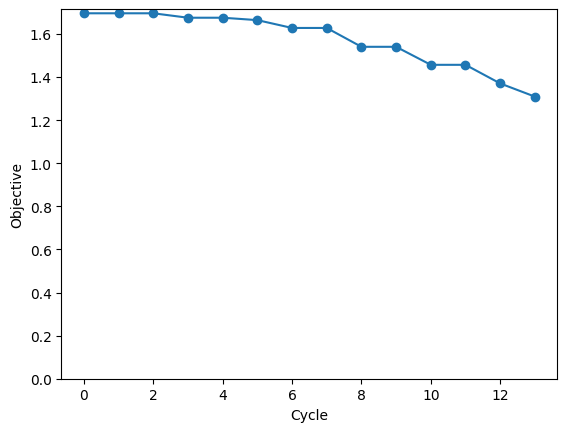

In [15]:
import matplotlib.pyplot as plt

print(objective_by_iter.keys())

fig, ax = plt.subplots()
tmp_history = [des.get_regret(max(objective_by_iter[1]))]
for i in range(1, CyclesNum):
    tmp_history.append(min(tmp_history[-1], des.get_regret(max(objective_by_iter[i]))))
ax.plot(range(CyclesNum), tmp_history, marker="o")
ax.set_xlabel("Cycle")
ax.set_ylim(0)
ax.set_ylabel("Objective")

In [16]:
# Save nested list object
import pickle
with open(out_dir / "objective_by_iter.pkl", "wb") as f:
    pickle.dump(objective_by_iter, f)
with open(out_dir / "sample_by_iter.pkl", "wb") as f:
    pickle.dump(sample_by_iter, f)